# Customer Behavior EDA

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [ ]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module so notebook execution always uses the latest code.
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

df = data_access_module.load_customer_behavior_data(
    use_sample=USE_SAMPLE,
    project_root=PROJECT_ROOT,
)

print(f"Loaded {len(df):,} records with {df['user_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
print(f"Columns: {list(df.columns)}\n")
df.head()

Loaded 9,356 records with 934 unique customers
Date range: 2015-06-01 to 2015-07-01
Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'cumulative_days', 'order_date', 'product_name', 'total_price', 'cumulative_reorder_per_customer']



,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,cumulative_days,order_date,product_name,total_price,cumulative_reorder_per_customer
0,2127348,42489,1,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Organic Raw Walnut Banana Meals To-Go,1,1
1,2127348,43352,2,0,52,prior,26,5,13,18.0,18.0,2015-06-13,Raspberries,1,1
2,2127348,40063,3,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Gluten Free Chocolate Chip Cookies,1,2
3,2127348,8048,4,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Packaged Grape Tomatoes,1,3
4,2127348,46516,5,1,52,prior,26,5,13,18.0,18.0,2015-06-13,Sesame Bagels,1,4


# Customer Behavior EDA

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in cell 1 for full dataset analysis (production)
- Set `USE_SAMPLE = True` in cell 1 for quick sample testing (development)

Objective: Analyze customer ordering cadence, reorder intensity, and basket behavior.

In [2]:
customer_kpi = (
    df.groupby("user_id")
    .agg(
        total_orders=("order_number", "max"),
        total_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
        cumulative_reorder_last=("cumulative_reorder_per_customer", "max"),
    )
    .reset_index()
)

display(customer_kpi.describe(include="all"))

summary_by_reordered = (
    df.groupby("reordered")
    .agg(
        avg_days_since_prior_order=("days_since_prior_order", "mean"),
        median_order_number=("order_number", "median"),
        median_cumulative_reorder=("cumulative_reorder_per_customer", "median"),
        sample_size=("order_id", "count"),
    )
)
summary_by_reordered

,user_id,total_orders,total_lines,reorder_rate,avg_days_between_orders,cumulative_reorder_last
count,934.000000,934.00000,934.000000,934.000000,934.000000,934.000000
mean,102646.137045,16.64561,10.017131,0.594517,9.784480,5.938972
std,58553.666110,17.36370,7.207811,0.333806,8.848809,5.734901
min,52.000000,1.00000,1.000000,0.000000,0.000000,0.000000
25%,51330.000000,4.00000,5.000000,0.333333,3.000000,2.000000
50%,102861.500000,10.00000,8.000000,0.625000,7.000000,4.000000
75%,153112.750000,23.00000,14.000000,0.894737,13.750000,8.000000
max,206074.000000,99.00000,44.000000,1.000000,30.000000,33.000000


,avg_days_since_prior_order,median_order_number,median_cumulative_reorder,sample_size
reordered,,,,
0,9.783408,6.0,2.0,3809
1,9.700559,16.0,5.0,5547


## Bivariate Comparison

This section was moved from the overview notebook and consolidated here for customer behavior interpretation.

## - Reorder Behavior

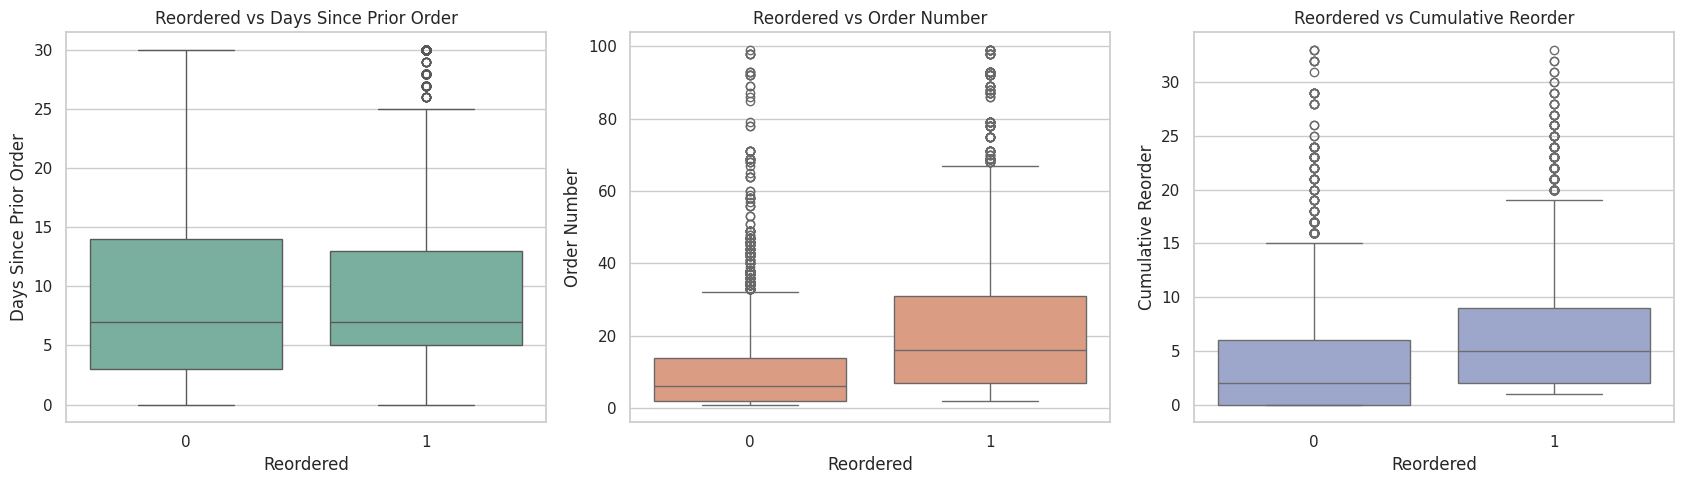

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(x="reordered", y="days_since_prior_order", data=df, ax=axes[0], color="#72B6A1")
axes[0].set_title("Reordered vs Days Since Prior Order")
axes[0].set_xlabel("Reordered")
axes[0].set_ylabel("Days Since Prior Order")

sns.boxplot(x="reordered", y="order_number", data=df, ax=axes[1], color="#E99675")
axes[1].set_title("Reordered vs Order Number")
axes[1].set_xlabel("Reordered")
axes[1].set_ylabel("Order Number")

sns.boxplot(x="reordered", y="cumulative_reorder_per_customer", data=df, ax=axes[2], color="#95A3D3")
axes[2].set_title("Reordered vs Cumulative Reorder")
axes[2].set_xlabel("Reordered")
axes[2].set_ylabel("Cumulative Reorder")

plt.tight_layout()
plt.show()

In [4]:
# Compare metrics between reordered and non-reordered items
reordered_yes = df[df["reordered"] == 1]
reordered_no = df[df["reordered"] == 0]

comparison_stats = {
    "days_since_prior_order": reordered_yes["days_since_prior_order"].mean() - reordered_no["days_since_prior_order"].mean(),
    "order_number": reordered_yes["order_number"].median() - reordered_no["order_number"].median(),
    "cumulative_reorder": reordered_yes["cumulative_reorder_per_customer"].median() - reordered_no["cumulative_reorder_per_customer"].median(),
}

pd.Series(comparison_stats, name="difference").to_frame()

,difference
days_since_prior_order,-0.082849
order_number,10.000000
cumulative_reorder,3.000000


## Key Insight Notes
- If days_since_prior_order difference is negative, reordered users tend to come back sooner.
- Positive median order_number difference indicates reorders increase with customer order history.
- Positive cumulative_reorder median difference indicates reorder behavior is reinforced over time.

## - Order & Reorder Behavior / Day time 

In [5]:
order_level = (
    df.groupby("order_id")
    .agg(
        order_dow=("order_dow", "first"),
        order_hour_of_day=("order_hour_of_day", "first"),
        total_products=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
        days_since_prior_order=("days_since_prior_order", "first"),
    )
    .reset_index()
)

print("Order-Level Summary:")
display(order_level.drop(columns=["order_id"]).describe(include="all"))

Order-Level Summary:


,order_dow,order_hour_of_day,total_products,reorder_rate,days_since_prior_order
count,938.000000,938.000000,938.000000,938.000000,938.000000
mean,2.637527,13.529851,9.974414,0.595033,9.768657
std,2.003934,4.179748,7.137720,0.334884,8.835313
min,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,10.000000,5.000000,0.333333,3.000000
50%,2.000000,13.000000,8.000000,0.625000,7.000000
75%,4.000000,16.000000,13.000000,0.900000,13.000000
max,6.000000,23.000000,44.000000,1.000000,30.000000


In [6]:
day_map = {
    0: "Sun", 1: "Mon", 2: "Tue",
    3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat"
}

order_level["day_name"] = order_level["order_dow"].map(day_map)
order_level["day_name"] = pd.Categorical(
    order_level["day_name"],
    categories=["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True
)

customer_kpi = (
    order_level.groupby(["day_name", "order_hour_of_day"], observed=False)
    .agg(
        avg_orders=("order_id", "count"),
        avg_products_per_order=("total_products", "mean"),
        avg_reorder_rate=("reorder_rate", "mean"),
        avg_days_between_orders=("days_since_prior_order", "mean"),
    )
    .reset_index()
    .sort_values(["day_name", "order_hour_of_day"])
)

print("Order-Customer KPI Summary:")
display(customer_kpi.describe(include="all"))

Order-Customer KPI Summary:


,day_name,order_hour_of_day,avg_orders,avg_products_per_order,avg_reorder_rate,avg_days_between_orders
count,154,154.000000,154.000000,130.000000,130.000000,130.000000
unique,7,NaN,NaN,NaN,NaN,NaN
top,Sun,NaN,NaN,NaN,NaN,NaN
freq,22,NaN,NaN,NaN,NaN,NaN
mean,NaN,12.318182,6.090909,10.074437,0.604520,9.268553
std,NaN,6.671277,5.161906,4.028443,0.161049,3.832396
min,NaN,0.000000,0.000000,1.000000,0.000000,0.000000
25%,NaN,7.000000,2.000000,8.000000,0.511111,7.000000
50%,NaN,12.500000,5.000000,9.625000,0.590854,9.400568
75%,NaN,18.000000,10.000000,11.809524,0.683141,11.534091


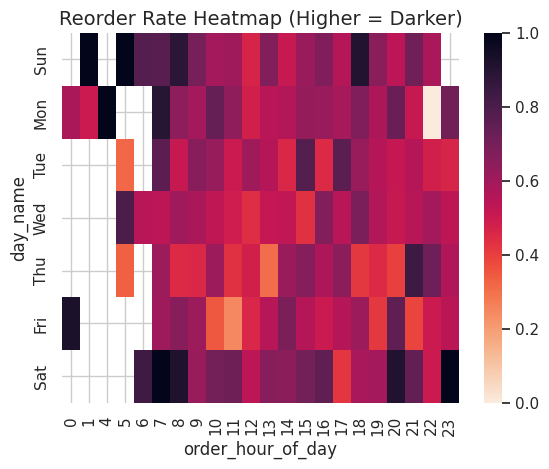

In [7]:
pivot = customer_kpi.pivot(
    index="day_name",
    columns="order_hour_of_day",
    values="avg_reorder_rate"
)

sns.heatmap(pivot, cmap="rocket_r")
plt.title("Reorder Rate Heatmap (Higher = Darker)", fontsize=14)
plt.show()

<Axes: xlabel='order_hour_of_day', ylabel='avg_reorder_rate'>

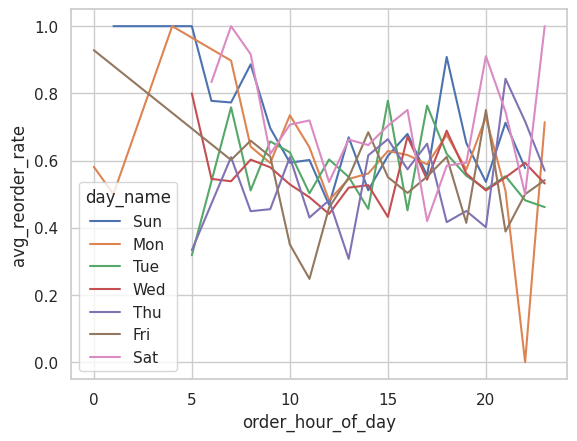

In [8]:
sns.lineplot(
    data=customer_kpi,
    x="order_hour_of_day",
    y="avg_reorder_rate",
    hue="day_name"
    )

<Axes: xlabel='day_name', ylabel='reorder_rate'>

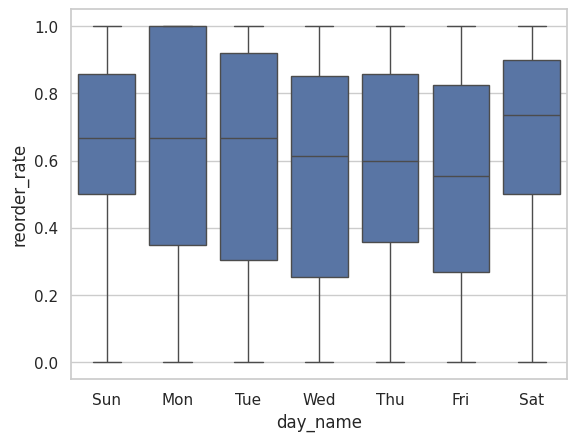

In [9]:
sns.boxplot(
    data=order_level,
    x="day_name",
    y="reorder_rate"
    )

## Segmentation Analysis

### 1 . Customer segmentation (RFM, cohort groups)

การแบ่งกลุ่มลูกค้า

RFM = Recency, Frequency, Monetary
- Recency → ลูกค้าซื้อล่าสุดเมื่อไหร่
- Frequency → ซื้อบ่อยแค่ไหน
- Monetary → ใช้เงินเยอะแค่ไหน
ใช้แบ่งลูกค้าเป็น: (VIP / Loyal, ลูกค้าใหม่, ลูกค้าที่กำลังจะหาย)

ส่วน Cohort group

คือการแบ่งตาม “ช่วงเวลาเริ่มใช้งาน”
เช่น ลูกค้าที่สมัครเดือนเดียวกัน

### -Rate Of Number of Purchase each Product Name

In [10]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("user_id")
    .agg(
        recency=("order_date", lambda x: (snapshot_date - x.max()).days),
        frequency=("order_id", "nunique"),
        monetary=("total_price", "median"),
    )
    .reset_index()
)

rfm["recency_score"] = pd.qcut(
    rfm["recency"].rank(method="first", ascending=False),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)
rfm["monetary_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4],
)

rfm["rfm_score"] = (
    rfm["recency_score"].astype(int)
    + rfm["frequency_score"].astype(int)
    + rfm["monetary_score"].astype(int)
)
rfm["segment"] = pd.cut(
    rfm["rfm_score"],
    bins=[0, 5, 8, 12],
    labels=["At Risk", "Regular", "Loyal"],
    include_lowest=True,
)

rfm.head()

,user_id,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
0,52,19,1,1.0,1,1,1,3,At Risk
1,551,16,1,1.0,1,1,1,3,At Risk
2,729,8,1,1.0,2,1,1,4,At Risk
3,997,24,1,1.0,1,1,1,3,At Risk
4,1951,9,1,1.0,2,1,1,4,At Risk


### 2. Product preferences by customer segment
Use the transaction-level dataset joined with the RFM segment labels, because product fields do not exist in the aggregated `rfm` table.

ลูกค้าแต่ละกลุ่มชอบสินค้าอะไร
ตัวอย่าง:

- VIP → ชอบสินค้าแพง
- ลูกค้าใหม่ → ชอบของลดราคา`

💡 ใช้ทำ:
- Recommendation
- Marketing targeting

### - Rate 

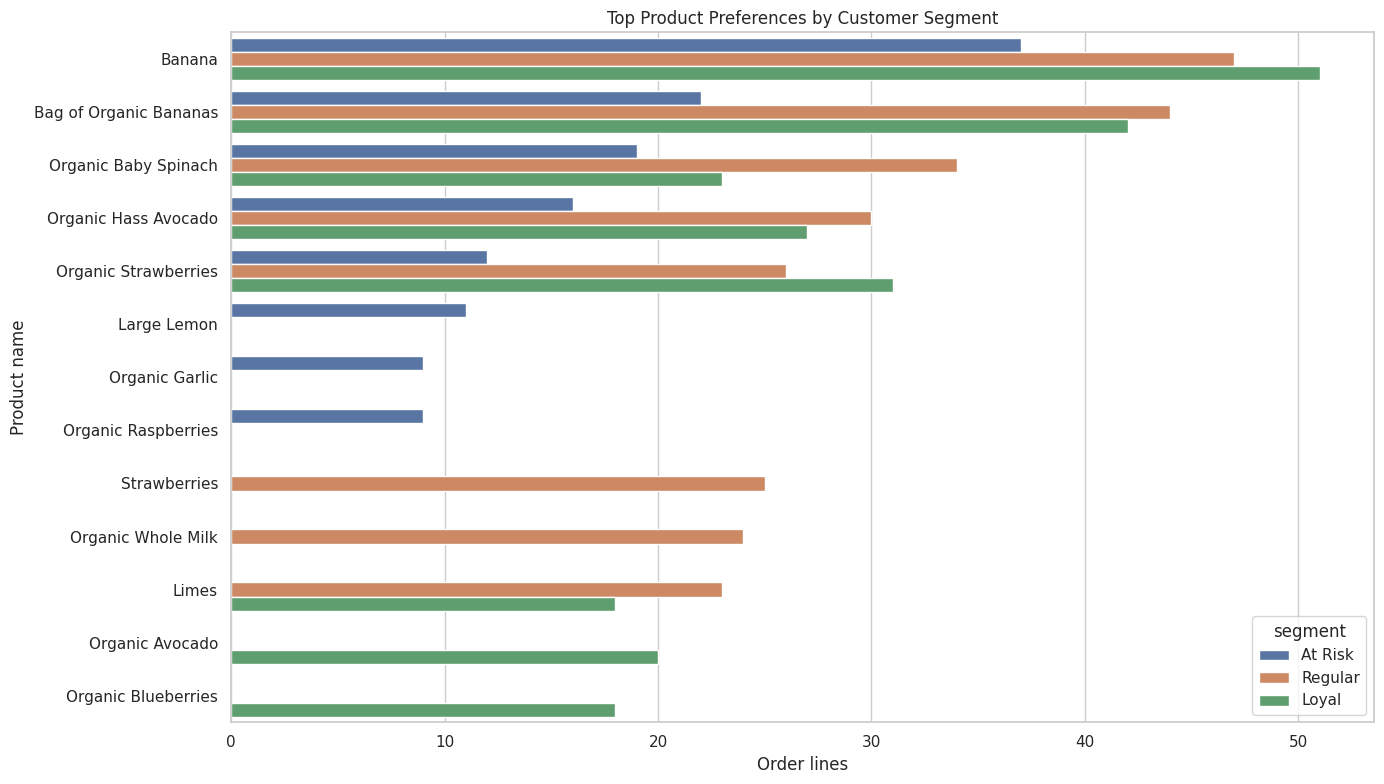

,segment,product_name,order_lines
0,At Risk,Banana,37
1,At Risk,Bag of Organic Bananas,22
2,At Risk,Organic Baby Spinach,19
3,At Risk,Organic Hass Avocado,16
4,At Risk,Organic Strawberries,12
5,At Risk,Large Lemon,11
6,At Risk,Organic Garlic,9
7,At Risk,Organic Raspberries,9
8,Regular,Banana,47
9,Regular,Bag of Organic Bananas,44


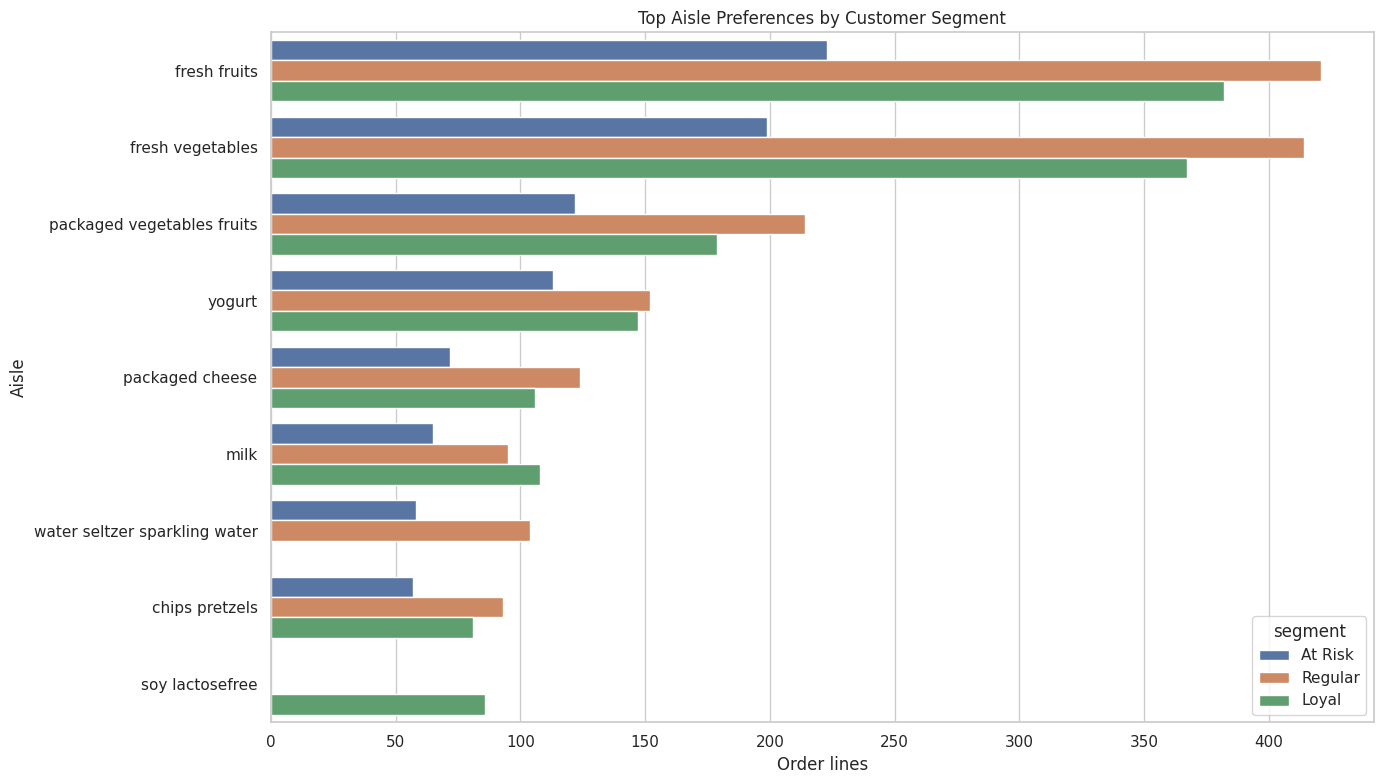

,segment,aisle,order_lines
0,At Risk,fresh fruits,223
1,At Risk,fresh vegetables,199
2,At Risk,packaged vegetables fruits,122
3,At Risk,yogurt,113
4,At Risk,packaged cheese,72
5,At Risk,milk,65
6,At Risk,water seltzer sparkling water,58
7,At Risk,chips pretzels,57
8,Regular,fresh fruits,421
9,Regular,fresh vegetables,414


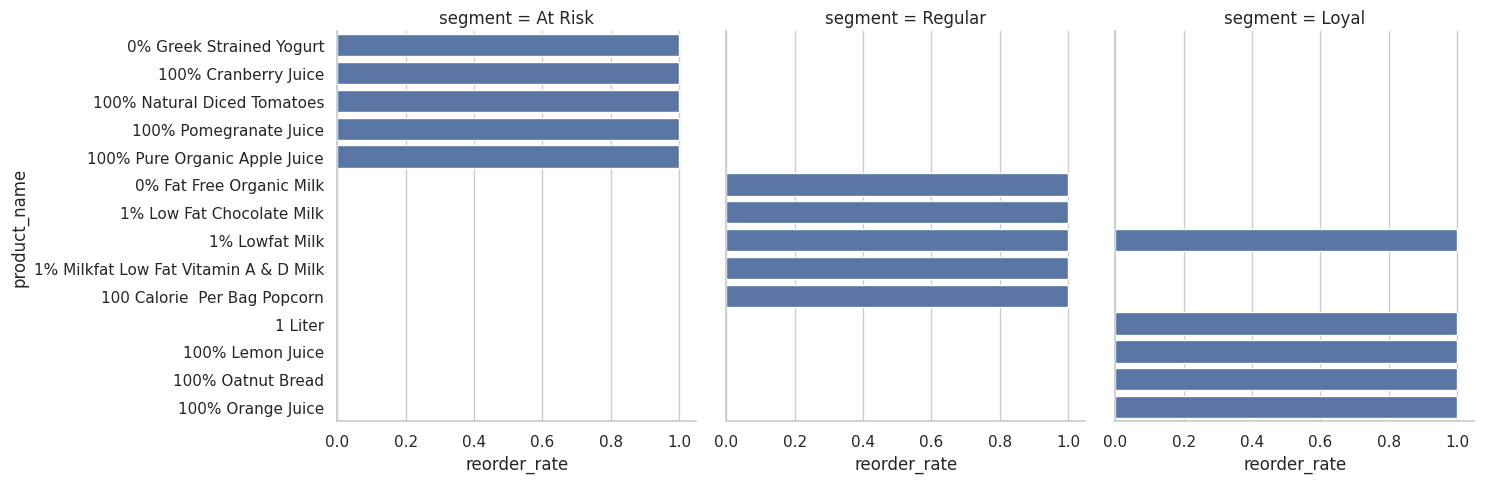

,segment,product_name,order_lines,reorder_rate
0,At Risk,0% Greek Strained Yogurt,1,1.0
3,At Risk,100% Cranberry Juice,1,1.0
5,At Risk,100% Natural Diced Tomatoes,1,1.0
6,At Risk,100% Pomegranate Juice,1,1.0
7,At Risk,100% Pure Organic Apple Juice,1,1.0
1502,Regular,0% Fat Free Organic Milk,1,1.0
1504,Regular,1% Low Fat Chocolate Milk,1,1.0
1505,Regular,1% Lowfat Milk,1,1.0
1506,Regular,1% Milkfat Low Fat Vitamin A & D Milk,1,1.0
1507,Regular,100 Calorie Per Bag Popcorn,1,1.0


In [11]:
segment_txn = df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

# Ensure aisle exists for aisle-level preference analysis.
if "aisle" not in segment_txn.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "aisle"]]
    segment_txn = segment_txn.merge(product_dim, on="product_id", how="left")

segment_product_pref = (
    segment_txn.groupby(["segment", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_products_by_segment = (
    segment_product_pref.sort_values(
        ["segment", "order_lines", "product_name"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

segment_aisle_pref = (
    segment_txn.dropna(subset=["aisle"])
    .groupby(["segment", "aisle"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)

top_aisle_by_segment = (
    segment_aisle_pref.sort_values(
        ["segment", "order_lines", "aisle"],
        ascending=[True, False, True],
    )
    .groupby("segment", observed=False)
    .head(8)
    .reset_index(drop=True)
)

top_reordered_by_segment = (
    segment_txn.groupby(["segment", "product_name"])
    .agg(
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)

top_reordered_by_segment = (
    top_reordered_by_segment
    .sort_values(["segment", "reorder_rate"], ascending=[True, False])
    .groupby("segment")
    .head(5)
)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_by_segment,
    x="order_lines",
    y="product_name",
    hue="segment",
)
plt.title("Top Product Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Product name")
plt.tight_layout()
plt.show()

display(top_products_by_segment)



plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_aisle_by_segment,
    x="order_lines",
    y="aisle",
    hue="segment",
)
plt.title("Top Aisle Preferences by Customer Segment")
plt.xlabel("Order lines")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

display(top_aisle_by_segment)


sns.catplot(
    data=top_reordered_by_segment,
    x="reorder_rate",
    y="product_name",
    col="segment",
    kind="bar",
    height=5,
    aspect=1
)
plt.show()

display(top_reordered_by_segment)

### 3. Retention / Churn analysis

Retention = ลูกค้ายัง active และกลับมาซื้อซ้ำในช่วงเวลาถัดไป
Churn = ลูกค้าไม่กลับมาซื้อภายในหน้าต่างเวลาที่กำหนด (inactivity threshold)

Framework ที่แนะนำ (ใช้ order_date):
1. สร้างเดือนของคำสั่งซื้อ: order_month
2. หา first_month ต่อ user เป็น cohort month
3. นับจำนวน user ที่ active ในแต่ละ month_index (0, 1, 2, ...)
4. คำนวณ retention_rate = active_users / cohort_size
5. กำหนด churn แบบธุรกิจ: เช่น ไม่สั่งซื้อเกิน 30 วัน = churn

หมายเหตุ: ใน Instacart ช่วงเวลาข้อมูลค่อนข้างสั้น การตั้ง threshold 30 วันมักเข้าใจง่ายและตีความได้ดี

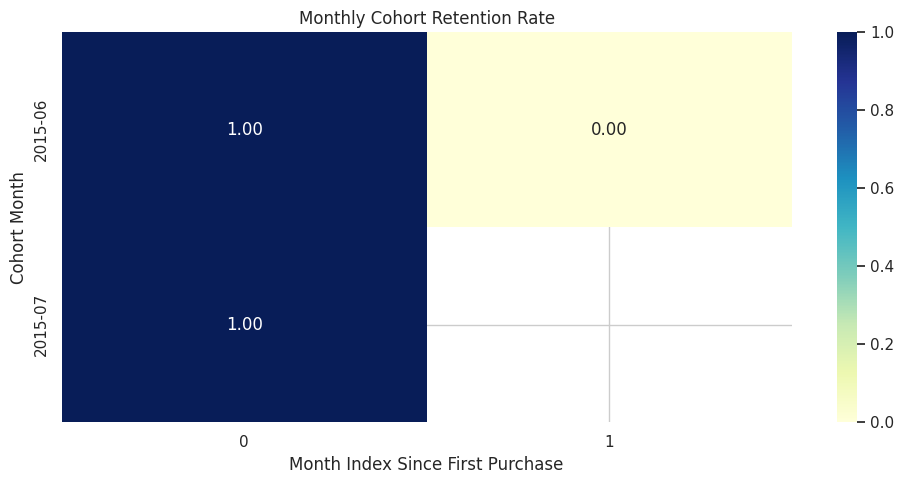

,cohort_month,month_index,active_users,cohort_size,retention_rate
0,2015-06,0,859,859,1.000000
1,2015-06,1,1,859,0.001164
2,2015-07,0,75,75,1.000000


,segment,customers,churn_30d_rate,median_days_since_last_order
0,At Risk,233,0.184549,14.0
1,Regular,356,0.078652,8.0
2,Loyal,345,0.043478,6.0


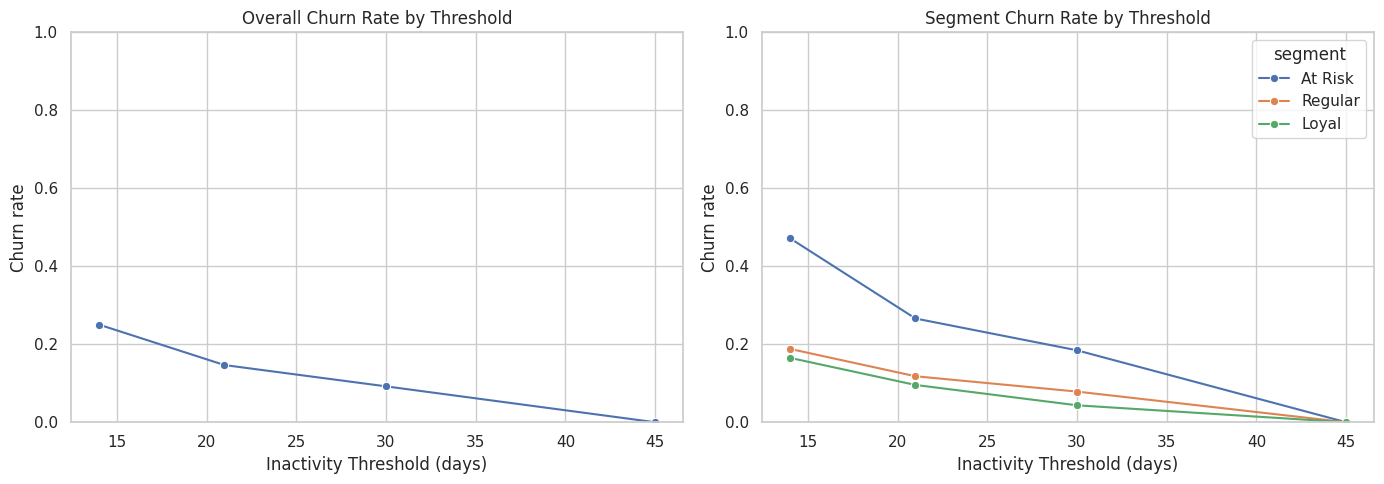

,threshold_days,churn_rate
0,14,0.250535
1,21,0.146681
2,30,0.092077
3,45,0.000000


,segment,churn_rate,threshold_days
0,At Risk,0.472103,14
3,At Risk,0.266094,21
6,At Risk,0.184549,30
9,At Risk,0.000000,45
1,Regular,0.188202,14
4,Regular,0.117978,21
7,Regular,0.078652,30
10,Regular,0.000000,45
2,Loyal,0.165217,14
5,Loyal,0.095652,21


In [12]:
# --- Retention (Monthly Cohort) + Churn (Inactivity) using order_date ---
orders_user = (
    df[["user_id", "order_id", "order_date"]]
    .drop_duplicates()
    .copy()
)

orders_user["order_month"] = orders_user["order_date"].dt.to_period("M")
first_month = orders_user.groupby("user_id")["order_month"].min().rename("cohort_month")
orders_user = orders_user.merge(first_month, on="user_id", how="left")

orders_user["month_index"] = (
    orders_user["order_month"].astype(int) - orders_user["cohort_month"].astype(int)
)

cohort_active = (
    orders_user.groupby(["cohort_month", "month_index"], observed=False)["user_id"]
    .nunique()
    .rename("active_users")
    .reset_index()
)
cohort_size = (
    orders_user.groupby("cohort_month", observed=False)["user_id"]
    .nunique()
    .rename("cohort_size")
    .reset_index()
)
cohort_retention = cohort_active.merge(cohort_size, on="cohort_month", how="left")
cohort_retention["retention_rate"] = cohort_retention["active_users"] / cohort_retention["cohort_size"]

retention_pivot = cohort_retention.pivot(
    index="cohort_month",
    columns="month_index",
    values="retention_rate",
)

plt.figure(figsize=(10, 5))
sns.heatmap(retention_pivot, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Monthly Cohort Retention Rate")
plt.xlabel("Month Index Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

display(cohort_retention.sort_values(["cohort_month", "month_index"]).head(20))

# Churn base table from last order date
snapshot_date = orders_user["order_date"].max() + pd.Timedelta(days=1)
last_order = orders_user.groupby("user_id")["order_date"].max().rename("last_order_date")
churn_df = last_order.to_frame().reset_index()
churn_df["days_since_last_order"] = (snapshot_date - churn_df["last_order_date"]).dt.days

# Churn at 30 days (kept for simple baseline report)
churn_df["is_churn_30d"] = churn_df["days_since_last_order"] > 30
churn_by_segment = (
    churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")
    .groupby("segment", observed=False)
    .agg(
        customers=("user_id", "nunique"),
        churn_30d_rate=("is_churn_30d", "mean"),
        median_days_since_last_order=("days_since_last_order", "median"),
    )
    .reset_index()
)
display(churn_by_segment)

# Compare multiple churn thresholds
churn_thresholds = [14, 21, 30, 45]
churn_eval = churn_df.merge(rfm[["user_id", "segment"]], on="user_id", how="left")

for t in churn_thresholds:
    churn_eval[f"is_churn_{t}d"] = churn_eval["days_since_last_order"] > t

overall_churn_curve = pd.DataFrame(
    {
        "threshold_days": churn_thresholds,
        "churn_rate": [
            churn_eval[f"is_churn_{t}d"].mean()
            for t in churn_thresholds
        ],
    }
)

segment_churn_curve = pd.concat(
    [
        churn_eval.groupby("segment", observed=False)[f"is_churn_{t}d"]
        .mean()
        .rename("churn_rate")
        .reset_index()
        .assign(threshold_days=t)
        for t in churn_thresholds
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(
    data=overall_churn_curve,
    x="threshold_days",
    y="churn_rate",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Overall Churn Rate by Threshold")
axes[0].set_xlabel("Inactivity Threshold (days)")
axes[0].set_ylabel("Churn rate")
axes[0].set_ylim(0, 1)

sns.lineplot(
    data=segment_churn_curve,
    x="threshold_days",
    y="churn_rate",
    hue="segment",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Segment Churn Rate by Threshold")
axes[1].set_xlabel("Inactivity Threshold (days)")
axes[1].set_ylabel("Churn rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

display(overall_churn_curve)
display(segment_churn_curve.sort_values(["segment", "threshold_days"]))

In [13]:
cohort_users = orders_user[orders_user['cohort_month'] == '2015-06']['user_id'].unique()
print(len(cohort_users))

next_month = df[(df['user_id'].isin(cohort_users)) & (orders_user['order_month'] == '2015-07')]
print(len(next_month['user_id'].unique()))

859
43


### 4. Basket value or repeat rate by product category

### 5. Customer lifetime value (CLV) trends

### 6. User & Product Trend Deep Dive

This section adds:
- User trend (active users, orders per active user, reorder rate) by week/month
- Product trend (top N products/departments) with order lines and share of total
- Histogram supplements for behavior and growth distributions

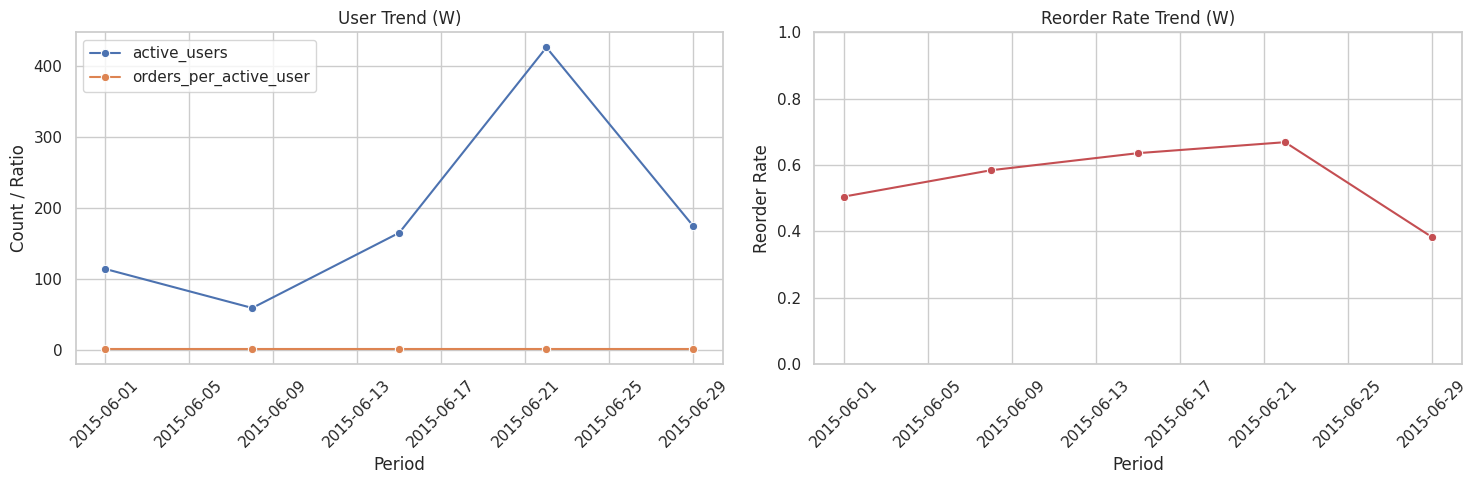

,period,active_users,orders,order_lines,reorder_rate,orders_per_active_user
0,2015-06-01,114,114,1095,0.505023,1.0
1,2015-06-08,59,59,527,0.584440,1.0
2,2015-06-15,165,165,1651,0.635978,1.0
3,2015-06-22,426,426,4568,0.669002,1.0
4,2015-06-29,174,174,1515,0.382838,1.0


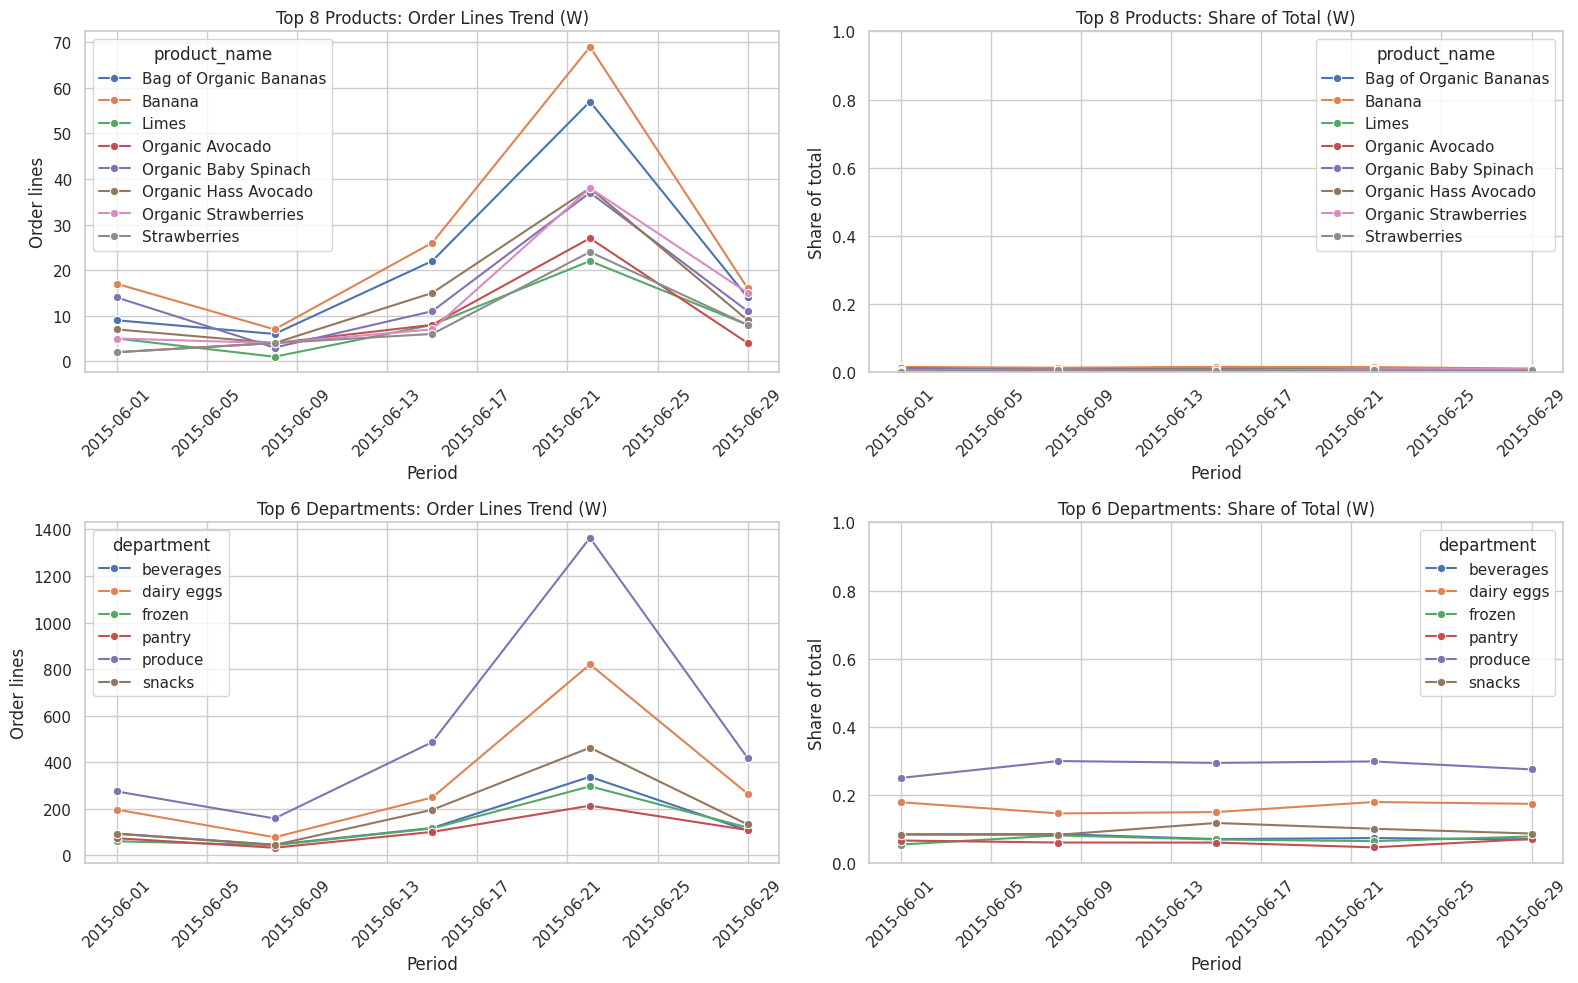

,period,product_name,order_lines,total_lines_period,share_of_total
0,2015-06-01,Bag of Organic Bananas,9,1095,0.008219
8,2015-06-08,Bag of Organic Bananas,6,527,0.011385
16,2015-06-15,Bag of Organic Bananas,22,1651,0.013325
24,2015-06-22,Bag of Organic Bananas,57,4568,0.012478
32,2015-06-29,Bag of Organic Bananas,14,1515,0.009241
1,2015-06-01,Banana,17,1095,0.015525
9,2015-06-08,Banana,7,527,0.013283
17,2015-06-15,Banana,26,1651,0.015748
25,2015-06-22,Banana,69,4568,0.015105
33,2015-06-29,Banana,16,1515,0.010561


,period,department,order_lines,total_lines_period,share_of_total
0,2015-06-01,beverages,93,1095,0.084932
6,2015-06-08,beverages,45,527,0.085389
12,2015-06-15,beverages,117,1651,0.070866
18,2015-06-22,beverages,337,4568,0.073774
24,2015-06-29,beverages,106,1515,0.069967
1,2015-06-01,dairy eggs,196,1095,0.178995
7,2015-06-08,dairy eggs,77,527,0.146110
13,2015-06-15,dairy eggs,248,1651,0.150212
19,2015-06-22,dairy eggs,820,4568,0.179510
25,2015-06-29,dairy eggs,264,1515,0.174257


In [14]:
# --- User trend + Product trend (Top N + Share) ---
TREND_FREQ = "W"  # use "M" for monthly
TOP_N_PRODUCTS = 8
TOP_N_DEPARTMENTS = 6

trend_df = df.copy()
trend_df["period"] = trend_df["order_date"].dt.to_period(TREND_FREQ).dt.to_timestamp()

# User trend metrics
user_trend = (
    trend_df.groupby("period", observed=False)
    .agg(
        active_users=("user_id", "nunique"),
        orders=("order_id", "nunique"),
        order_lines=("product_id", "count"),
        reorder_rate=("reordered", "mean"),
    )
    .reset_index()
)
user_trend["orders_per_active_user"] = user_trend["orders"] / user_trend["active_users"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=user_trend, x="period", y="active_users", marker="o", ax=axes[0], label="active_users")
sns.lineplot(data=user_trend, x="period", y="orders_per_active_user", marker="o", ax=axes[0], label="orders_per_active_user")
axes[0].set_title(f"User Trend ({TREND_FREQ})")
axes[0].set_xlabel("Period")
axes[0].set_ylabel("Count / Ratio")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=user_trend, x="period", y="reorder_rate", marker="o", ax=axes[1], color="#C44E52")
axes[1].set_title(f"Reorder Rate Trend ({TREND_FREQ})")
axes[1].set_xlabel("Period")
axes[1].set_ylabel("Reorder Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(user_trend)

# Product trend prep: ensure department exists
if "department" not in trend_df.columns:
    product_dim = data_access_module.load_product_dimension(
        use_sample=USE_SAMPLE,
        project_root=PROJECT_ROOT,
    )[["product_id", "department"]]
    trend_df = trend_df.merge(product_dim, on="product_id", how="left")

period_total_lines = (
    trend_df.groupby("period", observed=False)
    .size()
    .rename("total_lines_period")
    .reset_index()
)

# Top N products by overall order lines
top_products = (
    trend_df["product_name"].value_counts().head(TOP_N_PRODUCTS).index.tolist()
)
product_period = (
    trend_df[trend_df["product_name"].isin(top_products)]
    .groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
product_period["share_of_total"] = product_period["order_lines"] / product_period["total_lines_period"]

# Top N departments by overall order lines
top_departments = (
    trend_df["department"].dropna().value_counts().head(TOP_N_DEPARTMENTS).index.tolist()
)
dept_period = (
    trend_df[trend_df["department"].isin(top_departments)]
    .groupby(["period", "department"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
    .merge(period_total_lines, on="period", how="left")
)
dept_period["share_of_total"] = dept_period["order_lines"] / dept_period["total_lines_period"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(
    data=product_period,
    x="period",
    y="order_lines",
    hue="product_name",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title(f"Top {TOP_N_PRODUCTS} Products: Order Lines Trend ({TREND_FREQ})")
axes[0, 0].set_xlabel("Period")
axes[0, 0].set_ylabel("Order lines")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=product_period,
    x="period",
    y="share_of_total",
    hue="product_name",
    marker="o",
    ax=axes[0, 1],
)
axes[0, 1].set_title(f"Top {TOP_N_PRODUCTS} Products: Share of Total ({TREND_FREQ})")
axes[0, 1].set_xlabel("Period")
axes[0, 1].set_ylabel("Share of total")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="order_lines",
    hue="department",
    marker="o",
    ax=axes[1, 0],
)
axes[1, 0].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Order Lines Trend ({TREND_FREQ})")
axes[1, 0].set_xlabel("Period")
axes[1, 0].set_ylabel("Order lines")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.lineplot(
    data=dept_period,
    x="period",
    y="share_of_total",
    hue="department",
    marker="o",
    ax=axes[1, 1],
)
axes[1, 1].set_title(f"Top {TOP_N_DEPARTMENTS} Departments: Share of Total ({TREND_FREQ})")
axes[1, 1].set_xlabel("Period")
axes[1, 1].set_ylabel("Share of total")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(product_period.sort_values(["product_name", "period"]).head(30))
display(dept_period.sort_values(["department", "period"]).head(30))

### 7. Histogram Supplements

Use histograms to understand distribution shape (not time trend):
- days_since_prior_order
- order frequency per user
- product growth rate between periods

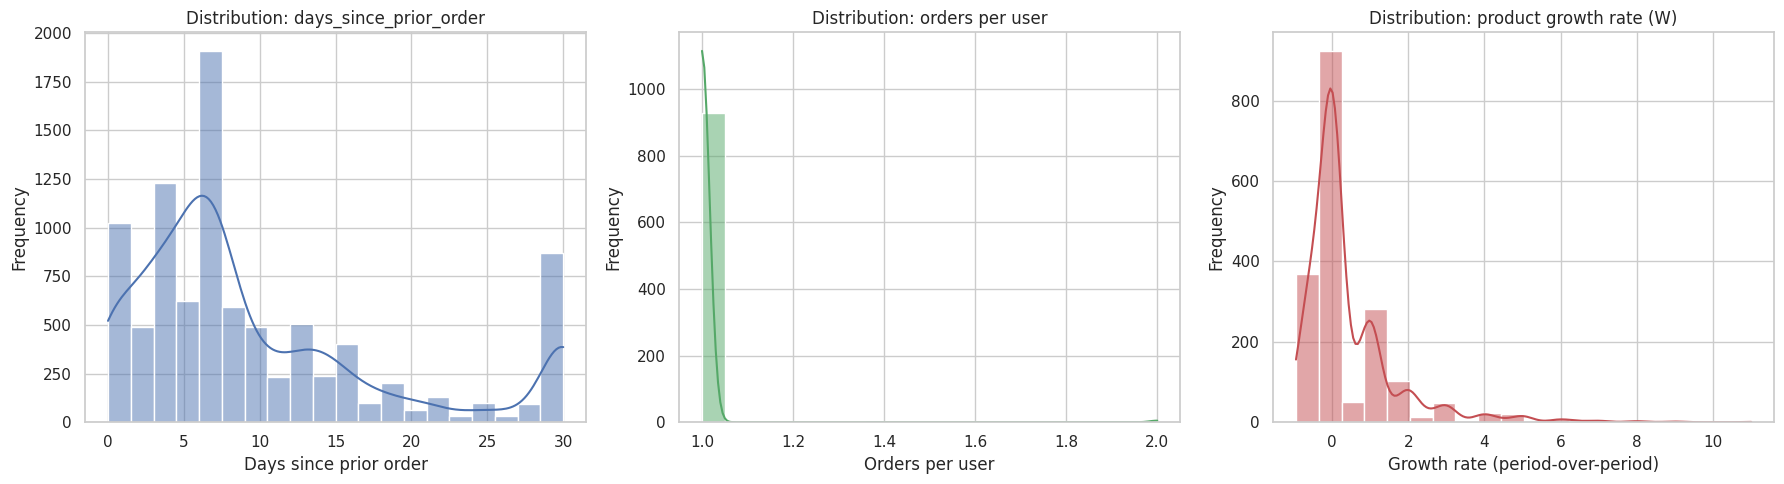

,orders_per_user
count,934.000000
mean,1.004283
std,0.065337
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,2.000000


,product_growth_rate
count,1855.000000
mean,0.426558
std,1.257056
min,-0.944444
25%,0.000000
50%,0.000000
75%,1.000000
max,11.000000


In [15]:
# --- Histogram supplements ---

# 1) Distribution of days_since_prior_order
days_dist = df["days_since_prior_order"].dropna()

# 2) Distribution of order frequency per user
user_order_freq = (
    df.groupby("user_id", observed=False)["order_id"]
    .nunique()
    .rename("orders_per_user")
)

# 3) Distribution of product growth rate between periods
growth_base = (
    trend_df.groupby(["period", "product_name"], observed=False)
    .size()
    .rename("order_lines")
    .reset_index()
)
growth_base = growth_base.sort_values(["product_name", "period"])
growth_base["product_growth_rate"] = growth_base.groupby("product_name", observed=False)["order_lines"].pct_change()

# Keep finite growth values for histogram
growth_values = growth_base["product_growth_rate"].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(days_dist, bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution: days_since_prior_order")
axes[0].set_xlabel("Days since prior order")
axes[0].set_ylabel("Frequency")

sns.histplot(user_order_freq, bins=20, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Distribution: orders per user")
axes[1].set_xlabel("Orders per user")
axes[1].set_ylabel("Frequency")

sns.histplot(growth_values, bins=20, kde=True, ax=axes[2], color="#C44E52")
axes[2].set_title(f"Distribution: product growth rate ({TREND_FREQ})")
axes[2].set_xlabel("Growth rate (period-over-period)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

display(user_order_freq.describe().to_frame(name="orders_per_user"))
display(growth_values.describe().to_frame(name="product_growth_rate"))